# PEG1 (GSE111629) cohort w. XGBoost

In [2]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, GlobalAttention
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

/opt/conda/envs/rapids-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define the functional map

In [2]:
FUNCTIONAL_MAP = {
    'TSS200': 0, 'TSS1500': 1, '1stExon': 2, 
    "5'UTR": 3, 'Body': 4, "3'UTR": 5, 'Other': 6
}

## Build the Chromosome topologies

In [3]:
def build_chromosome_topologies(manifest_df, common_probes, max_linear_dist_bp=1000):
    manifest = manifest_df[manifest_df['IlmnID'].isin(common_probes)].copy()
    manifest['CHR'] = manifest['CHR'].astype(str).str.replace('chr', '')
    manifest = manifest[manifest['CHR'].isin([str(i) for i in range(1, 23)])]
    manifest['MAPINFO'] = manifest['MAPINFO'].astype(int)
    
    chr_topologies = {}
    
    for c in range(1, 23):
        chr_str = str(c)
        sub = manifest[manifest['CHR'] == chr_str].sort_values(by='MAPINFO').reset_index(drop=True)
        probe_list = sub['IlmnID'].tolist()
        probe_to_idx = {p: i for i, p in enumerate(probe_list)}
        positions = sub['MAPINFO'].values
        n_nodes = len(probe_list)
        
        # A. Encode primary functional annotation
        func_labels = np.full(n_nodes, FUNCTIONAL_MAP['Other'], dtype=np.int64)
        for idx, row in sub.iterrows():
            grps = str(row.get('UCSC_RefGene_Group', '')).split(';')
            if grps and grps[0] in FUNCTIONAL_MAP:
                func_labels[idx] = FUNCTIONAL_MAP[grps[0]]
                
        # B. EXPLICIT SELF LOOPS (Fixes Empty Edge Crash & Mathematically sound for GAT)
        edges = [[i, i] for i in range(n_nodes)]
        
        # C. 1D Linear Adjacency Edges
        for i in range(n_nodes - 1):
            if 0 < (positions[i+1] - positions[i]) <= max_linear_dist_bp:
                edges.append([i, i + 1])
                edges.append([i + 1, i])
                
        # D. Shared Genic Annotation Edges
        gene_groups = {}
        for idx, row in sub.iterrows():
            genes = str(row.get('UCSC_RefGene_Name', '')).split(';')
            if genes and genes[0] not in ('', 'nan'):
                gene = genes[0]
                gene_groups.setdefault(gene, []).append(idx)
                
        for members in gene_groups.values():
            if 1 < len(members) <= 50:
                for i in range(len(members)):
                    for j in range(i + 1, len(members)):
                        edges.append([members[i], members[j]])
                        edges.append([members[j], members[i]])
                        
        # Because we initialized with self-loops, 'edges' is guaranteed non-empty
        edge_arr = np.unique(np.array(edges), axis=0).T
        edge_index = torch.tensor(edge_arr, dtype=torch.long)
            
        chr_topologies[c] = {
            'probes': probe_list,
            'edge_index': edge_index,
            'func_type': torch.tensor(func_labels, dtype=torch.long),
            'n_nodes': n_nodes
        }
        
    return chr_topologies

## PyTorch dataset and Trasposed Collator

In [4]:
LABEL_MAP = {'Control': 0.0, 'PD': 1.0}

class WholeBloodMethylationDataset(Dataset):
    def __init__(self, m_matrix_df, pheno_df, cell_cols, chr_topologies):
        self.sample_ids = pheno_df.index.tolist()
        
        # Explicit label encoding for BCEWithLogitsLoss
        labels = pheno_df['Sample_Group'].map(LABEL_MAP)
        if labels.isna().any():
            unknown_labels = sorted(pheno_df.loc[labels.isna(), 'Sample_Group'].astype(str).unique().tolist())
            raise ValueError(f"Unexpected Sample_Group values: {unknown_labels}")
        self.labels = labels.to_numpy(dtype=np.float32)
        
        self.cell_props = pheno_df[cell_cols].values.astype(np.float32)
        self.chr_topologies = chr_topologies
        
        self.chr_m_values = {}
        for c in range(1, 23):
            probes = chr_topologies[c]['probes']
            # Safe slice: guarantees no missing probes because df was pre-subsetted
            self.chr_m_values[c] = m_matrix_df.loc[self.sample_ids, probes].values.astype(np.float32)
            
    def __len__(self):
        return len(self.sample_ids)
        
    def __getitem__(self, idx):
        chr_graphs = []
        for c in range(1, 23):
            raw_x = torch.from_numpy(self.chr_m_values[c][idx]).unsqueeze(1)
            topo = self.chr_topologies[c]
            
            data = Data(
                x=raw_x,
                edge_index=topo['edge_index'],
                func_type=topo['func_type']
            )
            chr_graphs.append(data)
            
        u = torch.from_numpy(self.cell_props[idx])
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return chr_graphs, u, y


def chromosome_collate_fn(batch):
    batched_chromosomes = []
    graphs_per_sample = [item[0] for item in batch]
    u_tensor = torch.stack([item[1] for item in batch])
    y_tensor = torch.stack([item[2] for item in batch])
    
    for chr_idx in range(22):
        chr_list = [graphs[chr_idx] for graphs in graphs_per_sample]
        batched_chromosomes.append(Batch.from_data_list(chr_list))
        
    return batched_chromosomes, u_tensor, y_tensor

## Chromosome-Parallel GAT Architecture

In [ ]:
class ChromosomeParallelGAT(nn.Module):
    def __init__(self, num_node_classes=7, chr_embed_dim=16, cell_prop_dim=6):
        super(ChromosomeParallelGAT, self).__init__()
        
        self.func_embedding = nn.Embedding(num_embeddings=num_node_classes, embedding_dim=8)
        
        # add_self_loops=False because we explicitly defined them in the topology builder
        self.gat1 = GATConv(in_channels=9, out_channels=8, heads=2, concat=True, add_self_loops=False)
        self.gat2 = GATConv(in_channels=16, out_channels=chr_embed_dim, heads=1, concat=True, add_self_loops=False)
        
        self.gate_nn = nn.Sequential(
            nn.Linear(chr_embed_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        self.pool = GlobalAttention(gate_nn=self.gate_nn)
        
        fused_dim = (22 * chr_embed_dim) + cell_prop_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        
    def forward(self, batched_chrs, u_cells):
        chr_embeddings = []
        for c_idx in range(22):
            batch = batched_chrs[c_idx]
            
            emb_func = self.func_embedding(batch.func_type)
            node_feat = torch.cat([batch.x, emb_func], dim=1)
            
            h = torch.relu(self.gat1(node_feat, batch.edge_index))
            h = torch.relu(self.gat2(h, batch.edge_index))
            
            chr_emb = self.pool(h, batch.batch)
            chr_embeddings.append(chr_emb)
            
        genome_vector = torch.cat(chr_embeddings, dim=1)
        fused = torch.cat([genome_vector, u_cells], dim=1)
        return self.classifier(fused)

    def extract_features(self, batched_chrs, u_cells):
        chr_embeddings = []
        for c_idx in range(22):
            batch = batched_chrs[c_idx]
            
            emb_func = self.func_embedding(batch.func_type)
            node_feat = torch.cat([batch.x, emb_func], dim=1)
            
            h = torch.relu(self.gat1(node_feat, batch.edge_index))
            h = torch.relu(self.gat2(h, batch.edge_index))
            
            chr_emb = self.pool(h, batch.batch)
            chr_embeddings.append(chr_emb)
            
        genome_vector = torch.cat(chr_embeddings, dim=1)
        fused = torch.cat([genome_vector, u_cells], dim=1)
        return fused

## 5-Fold CV

In [ ]:
m_matrix_full = pd.read_feather("/workspace/data/peg1/GSE111629_data_test.feather")

This here fixes the m_matrix since the current parquet representation lacks all metadata/pheno columns including Sample_Name which causes failures further below...

In [ ]:
m_matrix_with_id = (
    m_matrix_full.copy()
    if 'Sample_Name' in m_matrix_full.columns
    else m_matrix_full.reset_index().rename(columns={m_matrix_full.index.name or 'index': 'Sample_Name'})
)

cols_to_keep = ['Sample_Name'] + [
    c for c in m_matrix_with_id.columns
    if c != 'Sample_Name' and c not in pheno_df.columns
]

m_matrix_full_reduced = m_matrix_with_id[cols_to_keep]
output_path = os.path.join("/workspace/data", "GSE111629_m_matrix_full_reduced.parquet")
m_matrix_full_reduced.to_parquet(output_path, index=False)
print(f"Saved to: {output_path}")

Saved to: /workspace/data/m_matrix_full_reduced.parquet


In [ ]:
m_matrix_full_reduced

In [33]:
m_matrix_full_reduced.head()

,cg16619049,cg23100540,cg18147296,cg13938959,cg12445832,cg23999112,cg11527153,cg27573606,cg04195702,cg08128007,...,cg19324023,cg09635994,cg19004771,cg20569369,cg26034629,cg25232725,cg05615487,cg22122449,cg08423507,cg19565306
Sample_Name,,,,,,,,,,,,,,,,,,,,,
GSM3035401,-0.391231,-1.572003,4.406984,0.778984,-0.906040,0.875549,4.271860,5.154080,3.761474,2.946690,...,3.354123,2.004086,1.929260,2.892161,4.913450,2.807751,4.782970,4.457486,5.246001,-6.148653
GSM3035402,-0.294673,-1.753355,3.439536,1.494787,-0.710042,0.808505,3.376785,5.194660,3.859485,3.366361,...,4.178481,1.938704,2.545114,2.160673,4.978455,2.912098,4.853534,4.736333,5.141731,-6.166355
GSM3035403,-1.009068,-1.895521,4.048525,0.860604,-0.790885,0.388188,4.297615,5.249513,3.691613,2.774799,...,3.367879,1.731055,1.931527,2.390308,5.219790,2.573055,4.933959,5.374524,5.142147,-6.167470
GSM3035404,-0.718404,-1.937458,3.281372,1.547149,-0.438353,1.122274,2.447532,5.334864,3.865556,4.230160,...,2.990683,2.210517,1.962918,2.375698,4.828473,3.111890,4.963863,3.586690,5.095090,-6.178808
GSM3035405,-0.817407,-1.902594,3.006591,1.674067,-0.705906,1.484803,3.157014,4.982922,4.555103,2.642256,...,3.262536,1.902270,1.696990,2.303311,5.145214,2.800162,4.069010,4.884013,5.142816,-6.166770


In [ ]:

pheno_path = "/workspace/data/peg1/GSE111629_pheno_data.parquet"
m_matrix_path = "/workspace/data/peg1/GSE111629_m_matrix_full_reduced.parquet"
manifest_path = "/workspace/data/infinium450k_manifest.parquet"

import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from scipy import interp
import os

# Initialize storage for interpolated curves
mean_fpr = np.linspace(0, 1, 100)
tprs = []
roc_aucs = []

mean_recall = np.linspace(0, 1, 100)
precisions = []
pr_aucs = []

feature_importances = []

LABEL_MAP = {'Control': 0, 'PD': 1}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing GAT Pipeline on: {device}")

pheno_df = pd.read_parquet(pheno_path)
if pheno_df.index.name != "Sample_Name":
    pheno_df = pheno_df.set_index("Sample_Name")
    
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
m_matrix_df = pd.read_parquet(m_matrix_path)
manifest_df = pd.read_parquet(manifest_path) 

m_matrix_df.set_index("Sample_Name", inplace=True)

# Strict validation to prevent index mismatch
common_probes = list(set(m_matrix_df.columns).intersection(set(manifest_df['IlmnID'])))
m_matrix_df = m_matrix_df[common_probes] # Discard unused columns to save RAM early
print(f"Total overlapping autosome probes: {len(common_probes):,}")

print("Building chromosome 1D adjacency and genic graphs...")
chr_topologies = build_chromosome_topologies(manifest_df, common_probes)

y = pheno_df['Sample_Group'].map(LABEL_MAP)
if y.isna().any():
    unknown_labels = sorted(pheno_df.loc[y.isna(), 'Sample_Group'].astype(str).unique().tolist())
    raise ValueError(f"Unexpected Sample_Group values: {unknown_labels}")
y = y.to_numpy(dtype=np.int64)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_aucs, pr_aucs = [], []
batch_size = 16  
epochs = 40
lr = 2e-4

## ==== SHAP
import shap

# Generate names for the 352 GAT embeddings (22 chromosomes * 16 dimensions)
feature_names = []
for chrom in range(1, 23):
    for dim in range(16):
        feature_names.append(f"Chr{chrom}_emb{dim}")

# Append the 6 cell type covariates exactly as they appear in u_cells
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
feature_names.extend(cell_cols)

# Storage for global SHAP analysis
all_shap_values = []
all_X_test = []

for fold, (train_idx, test_idx) in enumerate(skf.split(pheno_df, y)):
    print(f"\n--- Fold {fold + 1} ---")
    train_pheno = pheno_df.iloc[train_idx]
    test_pheno = pheno_df.iloc[test_idx]
    
    train_ds = WholeBloodMethylationDataset(m_matrix_df, train_pheno, cell_cols, chr_topologies)
    test_ds = WholeBloodMethylationDataset(m_matrix_df, test_pheno, cell_cols, chr_topologies)
    
    train_loader = DataLoader(train_ds, 
                              batch_size=batch_size, 
                              shuffle=True, 
                              collate_fn=chromosome_collate_fn,
                              num_workers=4,
                              pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=chromosome_collate_fn)
    
    model = ChromosomeParallelGAT().to(device)
    
    # Explicit dtype declaration for pos_weight
    train_labels = train_pheno['Sample_Group'].map(LABEL_MAP)
    if train_labels.isna().any():
        unknown_labels = sorted(train_pheno.loc[train_labels.isna(), 'Sample_Group'].astype(str).unique().tolist())
        raise ValueError(f"Unexpected Sample_Group values in training fold: {unknown_labels}")
    train_labels = train_labels.to_numpy(dtype=np.float32)
    positives = float((train_labels == 1.0).sum())
    negatives = float((train_labels == 0.0).sum())
    if positives == 0:
        raise ValueError("Training fold has no positive samples, cannot compute pos_weight")
    pos_weight = torch.tensor([negatives / positives], device=device, dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    
    # Training
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batched_chrs, u_cells, batch_y in train_loader:
            
            # Asynchronous memory transfer
            batched_chrs = [c.to(device, non_blocking=True) for c in batched_chrs]
            u_cells = u_cells.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            logits = model(batched_chrs, u_cells).squeeze(1)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # VRAM Fragmentation Protection
            del batched_chrs, u_cells, batch_y, logits, loss
            
    # Evaluation
    model.eval()

    def extract_embeddings(loader):
        embs, labels = [], []
        with torch.no_grad():
            for batch_x, u_cells, batch_y in loader:
                batch_x = batch_x.to(device, non_blocking=True)
                u_cells = u_cells.to(device, non_blocking=True)
                
                # Use native GPU cache logic to build batched_chrs here
                current_bs = batch_x.size(0)
                gpu_batches, col_mappings = graph_cache.get_batches(current_bs)
                batched_chrs = []
                for c in range(1, 23):
                    struct = gpu_batches[c]
                    dummy = DummyBatch()
                    dummy.x = batch_x[:, col_mappings[c]].reshape(-1, 1)
                    dummy.edge_index = struct['edge_index']
                    dummy.func_type = struct['func_type']
                    dummy.batch = struct['batch']
                    batched_chrs.append(dummy)
                
                # Extract the dense vector before the MLP head
                emb = model.extract_features(batched_chrs, u_cells)
                embs.append(emb.cpu().numpy())
                labels.append(batch_y.numpy())
                del batched_chrs, u_cells, batch_x
        return np.vstack(embs), np.concatenate(labels)

    X_train_xgb, y_train_xgb = extract_embeddings(train_loader)
    X_test_xgb, y_test_xgb = extract_embeddings(test_loader)
    
    # ---------------------------------------------------------
    # 2. Train GPU-Accelerated XGBoost
    # ---------------------------------------------------------
    xgb_clf = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
    
    xgb_clf.fit(X_train_xgb, y_train_xgb)
    preds = xgb_clf.predict_proba(X_test_xgb)[:, 1]
    
    # Save importances (Maps to Chromosome Embeddings + Cell Types)
    feature_importances.append(xgb_clf.feature_importances_)

    explainer = shap.TreeExplainer(xgb_clf)
    
    # Extract the SHAP values for the positive class (Parkinson's)
    # Note: Depending on the xgboost/shap version, explainer.shap_values might return a list for binary classification. 
    # If it returns a list, use [1] to get the positive class. If it returns an array, use it directly.
    fold_shap_values = explainer.shap_values(X_test_xgb)
    if isinstance(fold_shap_values, list):
        fold_shap_values = fold_shap_values[1]
        
    all_shap_values.append(fold_shap_values)
    all_X_test.append(X_test_xgb)
    
    # ---------------------------------------------------------
    # 3. Calculate Curves
    # ---------------------------------------------------------
    # ROC
    fpr, tpr, _ = roc_curve(y_test_xgb, preds)
    roc_auc = auc(fpr, tpr)
    roc_aucs.append(roc_auc)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    # PR
    precision, recall, _ = precision_recall_curve(y_test_xgb, preds)
    pr_auc = auc(recall, precision)
    pr_aucs.append(pr_auc)
    # Reverse for interpolation
    interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
    precisions.append(interp_precision)
    
    print(f"Fold {fold + 1} | XGBoost ROC AUC: {roc_auc:.4f} | PR AUC: {pr_auc:.4f}")
    
    del model, optimizer, train_ds, test_ds
    torch.cuda.empty_cache()

# ---------------------------------------------------------
# 4. Plotting Mean Curves with Variance Shadows
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot ROC
for i, tpr in enumerate(tprs):
    ax1.plot(mean_fpr, tpr, color='grey', alpha=0.3, lw=1)
    
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

mean_roc_auc = auc(mean_fpr, mean_tpr)
std_roc_auc = np.std(roc_aucs)

ax1.plot(mean_fpr, mean_tpr, color='b', lw=2, label=f'Mean ROC (AUC = {mean_roc_auc:.3f} $\pm$ {std_roc_auc:.3f})')
ax1.fill_between(mean_fpr, tprs_lower, tprs_upper, color='blue', alpha=0.1)
ax1.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', alpha=0.8)
ax1.set_xlim([-0.05, 1.05])
ax1.set_ylim([-0.05, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('GAT + XGBoost ROC Curve', fontsize=14)
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Plot Precision-Recall
for i, prec in enumerate(precisions):
    ax2.plot(mean_recall, prec, color='grey', alpha=0.3, lw=1)
    
mean_precision = np.mean(precisions, axis=0)
std_precision = np.std(precisions, axis=0)
prec_upper = np.minimum(mean_precision + std_precision, 1)
prec_lower = np.maximum(mean_precision - std_precision, 0)

mean_pr_auc = np.mean(pr_aucs)
std_pr_auc = np.std(pr_aucs)

ax2.plot(mean_recall, mean_precision, color='g', lw=2, label=f'Mean PR (AUC = {mean_pr_auc:.3f} $\pm$ {std_pr_auc:.3f})')
ax2.fill_between(mean_recall, prec_lower, prec_upper, color='green', alpha=0.1)
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([-0.05, 1.05])
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('GAT + XGBoost Precision-Recall Curve', fontsize=14)
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
os.makedirs("/workspace/results/peg1", exist_ok=True)
plt.savefig("/workspace/results/peg1/hybrid_xgb_curves.pdf", dpi=300)
plt.show()

# ---------------------------------------------------------
# SHAP Global Beeswarm Plot
# ---------------------------------------------------------
print("\nGenerating Global SHAP Beeswarm Plot...")

# Stack all folds together
global_shap_values = np.vstack(all_shap_values)
global_X_test = np.vstack(all_X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    global_shap_values, 
    features=global_X_test, 
    feature_names=feature_names,
    max_display=20,       # Shows the top 20 most impactful features
    plot_type="dot", 
    show=False            # Allows saving the figure before displaying
)

plt.title("SHAP Feature Importance: GAT + XGBoost", fontsize=14)
plt.tight_layout()
plt.savefig("/workspace/results/peg1/hybrid_shap_beeswarm.pdf", dpi=300)
plt.show()

Executing GAT Pipeline on: cuda
Total overlapping autosome probes: 421,114
Building chromosome 1D adjacency and genic graphs...

--- Fold 1 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 1 | ROC AUC: 0.6883 | PR AUC: 0.7273

--- Fold 2 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 2 | ROC AUC: 0.6839 | PR AUC: 0.7422

--- Fold 3 ---


...

Fold 3 | ROC AUC: 0.6846 | PR AUC: 0.7190

--- Fold 4 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 4 | ROC AUC: 0.6646 | PR AUC: 0.6952

--- Fold 5 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 5 | ROC AUC: 0.7167 | PR AUC: 0.7542

Mean GAT ROC AUC: 0.6876 ± 0.0167
Mean GAT PR AUC:  0.7276 ± 0.0202


## Extraction of important features and pathway enrichment analysis

**The intersection between the GAT attention scores and the statistically significant Δβ values yields the set of genes that will passed down for pathway analysis**

The first attempt sets the minimum effect size (Δβ) for filtering to 5% and an FDR of < 0.05.  
Yet, using both of these threshold values yields no significant CpGs to assess further.  
After setting the effect size threshold to 0.01 and keeping the FDR at < 0.05 there were still no results.

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import gseapy as gp
import matplotlib.pyplot as plt

def extract_gold_standard_network(drivers_csv, m_matrix_df, pheno_df, manifest_df, 
                                  top_gat_pool=5000, 
                                  min_delta_beta=0.05, 
                                  max_fdr=0.05):
    """
    Finds the intersection of high GAT attention and significant clinical fold-change.
    """
    print(f"Loading top {top_gat_pool} GAT-selected drivers...")
    drivers_df = pd.read_csv(drivers_csv).sort_values('Attention_Score', ascending=False).head(top_gat_pool)
    target_cpgs = drivers_df['IlmnID'].tolist()
    
    # 1. Calculate Differential Methylation for the GAT Pool
    print("Calculating clinical effect sizes and p-values...")
    sub_matrix = m_matrix_df[target_cpgs]
    pd_indices = pheno_df.index[pheno_df['Sample_Group'] == 'PD'].tolist()
    ctrl_indices = pheno_df.index[pheno_df['Sample_Group'] == 'Control'].tolist()
    
    records = []
    for cpg in target_cpgs:
        pd_vals = sub_matrix.loc[pd_indices, cpg]
        ctrl_vals = sub_matrix.loc[ctrl_indices, cpg]
        
        # Means & Beta conversion
        mean_m_pd = pd_vals.mean()
        mean_m_ctrl = ctrl_vals.mean()
        mean_beta_pd = (2 ** mean_m_pd) / ((2 ** mean_m_pd) + 1)
        mean_beta_ctrl = (2 ** mean_m_ctrl) / ((2 ** mean_m_ctrl) + 1)
        delta_beta = mean_beta_pd - mean_beta_ctrl
        
        # Statistical Significance (Welch's t-test)
        stat, p_val = ttest_ind(pd_vals, ctrl_vals, equal_var=False)
        
        records.append({
            'IlmnID': cpg,
            'Delta_Beta': delta_beta,
            'Abs_Delta_Beta': abs(delta_beta),
            'P_Value': p_val,
            'Direction': 'Hypermethylated' if delta_beta > 0 else 'Hypomethylated'
        })
        
    stats_df = pd.DataFrame(records)
    
    # Apply FDR Correction
    _, stats_df['FDR_Q'] = multipletests(stats_df['P_Value'], method='fdr_bh')[:2]
    
    # Merge with GAT Attention and Manifest Annotations
    merged_df = pd.merge(stats_df, drivers_df[['IlmnID', 'Attention_Score']], on='IlmnID')
    merged_df = pd.merge(merged_df, manifest_df[['IlmnID', 'CHR', 'MAPINFO', 'UCSC_RefGene_Name']], on='IlmnID')
    
    # ==========================================
    # 2. The Crucible: Apply Strict Biological Filters
    # ==========================================
    print(f"Applying filters: FDR < {max_fdr} & |Delta Beta| >= {min_delta_beta}...")
    robust_df = merged_df[
        (merged_df['FDR_Q'] < max_fdr) & 
        (merged_df['Abs_Delta_Beta'] >= min_delta_beta)
    ].copy()
    
    print(f"-> {len(robust_df)} robust CpGs survived out of {top_gat_pool}.")
    
    # Extract unique genes from the surviving robust probes
    robust_genes = []
    for gene_string in robust_df['UCSC_RefGene_Name'].dropna():
        genes = str(gene_string).split(';')
        robust_genes.extend(genes)
        
    unique_robust_genes = list(set([g for g in robust_genes if g.lower() != 'nan']))
    print(f"-> Yielding {len(unique_robust_genes)} gold-standard genes for pathway analysis.\\n")
    
    robust_df.to_csv("/workspace/results/gold_standard_pd_cpgs.csv", index=False)
    
    return unique_robust_genes, robust_df

def run_robust_gsea(gene_list):
    if len(gene_list) < 5:
        print("Not enough genes survived to run meaningful GSEA.")
        return None
        
    databases = [    
    'GO_Biological_Process_2026', 
    'Reactome_2022', 
    'KEGG_2021_Human',
    'Reactome_Pathways_2024',
    'GO_Molecular_Function_2026',
    'TRRUST_Transcription_Factors_2019',
    'TRANSFAC_and_JASPAR_PWMs',
    'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X',
    'WikiPathways_2024_Human',
    'SynGO_2024',
    'WikiPathways_2024_Human',
    'Elsevier_Pathway_Collection'
]
    print(f"Running GSEA on {len(gene_list)} genes...")
    
    enrichment = gp.enrichr(gene_list=gene_list, gene_sets=databases, organism='human', outdir=None)
    results_df = enrichment.results
    
    fdr_sig = results_df[results_df['Adjusted P-value'] < 0.05]
    print(f"Found {len(fdr_sig)} strictly significant pathways!")
    
    if len(fdr_sig) > 0:
        #
        # 1. Filter out murine experiments from the results dataframe
        human_results_df = results_df[~results_df['Term'].str.contains('mouse', case=False, na=False)].copy()

        # 2. Re-plot the sanitized human-only results
        fdr_sig_human = human_results_df[human_results_df['Adjusted P-value'] < 0.05]

        if len(fdr_sig_human) > 0:
            # Use the filtered dataframe to build the plot
            gp.barplot(
                human_results_df, 
                column="Adjusted P-value", 
                title="Gold-Standard PD EWAS Enrichment (Human)",
                top_term=15, 
                figsize=(8, 6)
            )
            plt.show()        
            #         
    else:
        print(results_df.head(10)[['Gene_set', 'Term', 'P-value', 'Adjusted P-value', 'Overlap']])
        
    return results_df


In [ ]:
pheno_path = "/workspace/data/peg1/GSE111629_pheno_data.parquet"
m_matrix_path = "/workspace/data/peg1/GSE111629_m_matrix_full_reduced.parquet"

pheno_df = pd.read_parquet(pheno_path)
m_matrix_df = pd.read_parquet(m_matrix_path)

m_matrix_df.set_index("Sample_Name", inplace=True)

manifest_path = "/workspace/data/infinium450k_manifest.parquet"
manifest_df = pd.read_parquet(manifest_path)


In [5]:
robust_genes, robust_cpg_df = extract_gold_standard_network(
    drivers_csv="/workspace/results/pd_ensemble_epigenetic_drivers.csv",
    m_matrix_df=m_matrix_df,
    pheno_df=pheno_df,
    manifest_df=manifest_df,
    top_gat_pool=5000,
    min_delta_beta=0.01,
    max_fdr=0.05
)
robust_pathways = run_robust_gsea(robust_genes)

Loading top 5000 GAT-selected drivers...
Calculating clinical effect sizes and p-values...
Applying filters: FDR < 0.05 & |Delta Beta| >= 0.01...
-> 0 robust CpGs survived out of 5000.
-> Yielding 0 gold-standard genes for pathway analysis.\n
Not enough genes survived to run meaningful GSEA.


**Alternative: Blood, as a proxy tissue, is a difficult source to gain significant and hi-magnitude methylation effect sizes from. Hence a more relaxed set of thresholds is applied**

Here, the top 10,000 CpG's from GAT are tried for intersection with Δβ values of 1.5% whereby significance is set to a nominal p-value of 0.05 instead of the FDR.

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import gseapy as gp
import matplotlib.pyplot as plt

def extract_blood_optimized_network(drivers_csv, m_matrix_df, pheno_df, manifest_df, 
                                    top_gat_pool=10000, 
                                    min_delta_beta=0.015, # 1.5% shift (realistic for blood)
                                    max_nominal_p=0.05):  # Trusting GAT to handle the FDR burden
    
    drivers_df = pd.read_csv(drivers_csv).sort_values('Attention_Score', ascending=False).head(top_gat_pool)
    target_cpgs = drivers_df['IlmnID'].tolist()
    
    sub_matrix = m_matrix_df[target_cpgs]
    pd_indices = pheno_df.index[pheno_df['Sample_Group'] == 'PD'].tolist()
    ctrl_indices = pheno_df.index[pheno_df['Sample_Group'] == 'Control'].tolist()
    
    records = []
    for cpg in target_cpgs:
        pd_vals = sub_matrix.loc[pd_indices, cpg]
        ctrl_vals = sub_matrix.loc[ctrl_indices, cpg]
        
        mean_m_pd = pd_vals.mean()
        mean_m_ctrl = ctrl_vals.mean()
        mean_beta_pd = (2 ** mean_m_pd) / ((2 ** mean_m_pd) + 1)
        mean_beta_ctrl = (2 ** mean_m_ctrl) / ((2 ** mean_m_ctrl) + 1)
        delta_beta = mean_beta_pd - mean_beta_ctrl
        
        stat, p_val = ttest_ind(pd_vals, ctrl_vals, equal_var=False)
        
        records.append({
            'IlmnID': cpg,
            'Delta_Beta': delta_beta,
            'Abs_Delta_Beta': abs(delta_beta),
            'Nominal_P': p_val,
            'Direction': 'Hypermethylated' if delta_beta > 0 else 'Hypomethylated'
        })
        
    stats_df = pd.DataFrame(records)
    merged_df = pd.merge(stats_df, drivers_df[['IlmnID', 'Attention_Score']], on='IlmnID')
    merged_df = pd.merge(merged_df, manifest_df[['IlmnID', 'CHR', 'MAPINFO', 'UCSC_RefGene_Name']], on='IlmnID')
    
    # Apply blood-optimized filters
    robust_df = merged_df[
        (merged_df['Nominal_P'] < max_nominal_p) & 
        (merged_df['Abs_Delta_Beta'] >= min_delta_beta)
    ].copy()
    
    print(f"-> {len(robust_df)} blood-optimized CpGs survived.")
    
    robust_genes = []
    for gene_string in robust_df['UCSC_RefGene_Name'].dropna():
        genes = str(gene_string).split(';')
        robust_genes.extend(genes)
        
    unique_robust_genes = list(set([g for g in robust_genes if g.lower() != 'nan']))
    print(f"-> Yielding {len(unique_robust_genes)} genes for pathway analysis.\n")
    
    return unique_robust_genes, robust_df

# Execute extraction
# optimized_genes, optimized_cpg_df = extract_blood_optimized_network(...)
# Then pass optimized_genes to your run_robust_gsea() function

In [8]:
optimized_genes, optimized_cpg_df = extract_blood_optimized_network(drivers_csv="/workspace/results/pd_ensemble_epigenetic_drivers.csv",
                                                                    m_matrix_df=m_matrix_df,
                                                                    pheno_df=pheno_df,
                                                                    manifest_df=manifest_df)

-> 41 blood-optimized CpGs survived.
-> Yielding 23 genes for pathway analysis.



Running GSEA on 23 genes...


Found 52 strictly significant pathways!


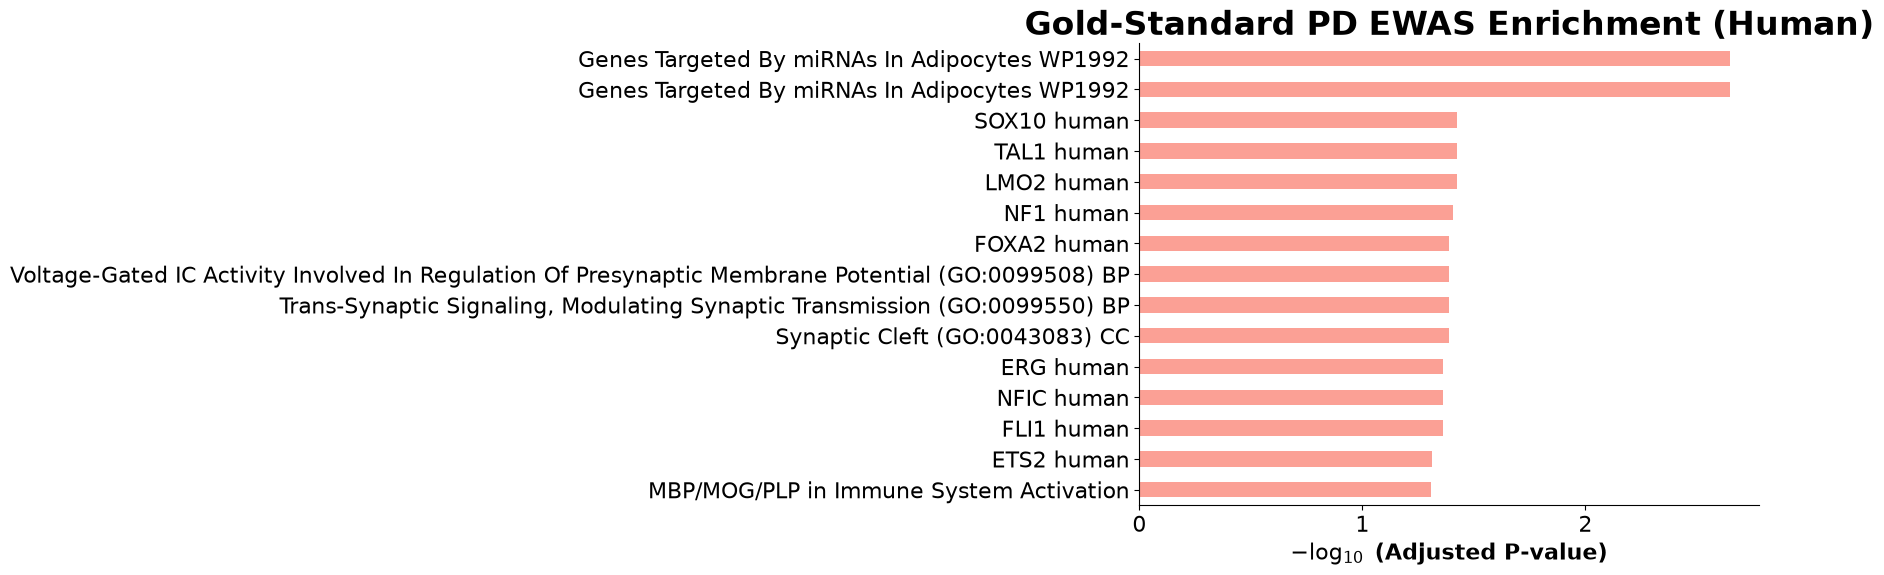

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2026,Potassium Ion Transport (GO:0006813),3/139,0.000525,0.049834,0,0,21.883456,165.248817,KCNG2;KCNE1;KCNJ6
1,GO_Biological_Process_2026,Potassium Ion Transmembrane Transport (GO:0071...,3/148,0.000631,0.049834,0,0,20.515862,151.171365,KCNG2;KCNE1;KCNJ6
2,GO_Biological_Process_2026,Action Potential (GO:0001508),2/71,0.002996,0.054360,0,0,27.478261,159.665620,KCNG2;KCNE1
3,GO_Biological_Process_2026,Hexose Phosphate Transport (GO:0015712),1/5,0.005737,0.054360,0,0,226.965909,1171.318505,SLC37A1
4,GO_Biological_Process_2026,Positive Regulation of Axon Extension Involved...,1/5,0.005737,0.054360,0,0,226.965909,1171.318505,DSCAM
...,...,...,...,...,...,...,...,...,...,...
821,Elsevier_Pathway_Collection,Proteins Involved in Age-Related Macular Degen...,1/148,0.157117,0.172445,0,0,6.131725,11.348391,COL18A1
822,Elsevier_Pathway_Collection,Proteins Involved in Hearing Loss,1/209,0.214746,0.230085,0,0,4.320149,6.645686,KCNE1
823,Elsevier_Pathway_Collection,Proteins Involved in Endometriosis,1/256,0.256558,0.268490,0,0,3.515508,4.782505,COL18A1
824,Elsevier_Pathway_Collection,Proteins Involved in Epilepsy,1/270,0.268595,0.274699,0,0,3.330179,4.377693,DSCAM


In [13]:
run_robust_gsea(optimized_genes)

In [ ]:
1